<a href="https://colab.research.google.com/github/Daniel-MENGEL/PCSI2/blob/main/Pendule_simple-ex-etudiant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pendule simple

**Notebook-rapport à rendre**

**Énoncé en ligne :** [http://www.pcsi2.net/fabert/wp-content/uploads/physique/Pendule-simple.pdf](http://www.pcsi2.net/fabert/wp-content/uploads/physique/Pendule-simple.pdf)

**Outil de pointage :** [PyMecaVideo](https://outilsphysiques.tuxfamily.org/wiki/index.php?title=Pymecavideo)

Noms :  Esteban, Pablo

Groupe :  1

Date de la séance :  22/06/2026

Ce notebook remplace le rapport séparé. Il doit présenter l'exploitation vidéo du pendule, la comparaison à une sinusoïde, le portrait de phase et l'étude énergétique.


<div style="background:#eaf4ff; border-left:6px solid #1f77b4; padding:12px 14px; border-radius:6px;">

## Objectifs et protocole

Décrire le montage vidéo, la mesure de $m$ et $l$, l'étalonnage de la vidéo et le pointage de la masse.

**Protocole rédigé :**

- Montage utilisé : un pendule constitué d'une bille métalique suspendue à un fil de coton
- Grandeurs mesurées directement : la masse m de la bille (à 1 g près) à l'aide d'une balance et la distance entre le point d'accroche du fil et le centre de la bille à l'aide d'une règle (à 0,5 cm près).
- Étalonnage de la vidéo : On se place face au plan d'oscillation du système et on regle 30 images par seconde
- Méthode de pointage : on a utilisé PyMécaVidéo et un pointage automatique
- Difficultés expérimentales ou sources d'incertitude : manque de luminosité, le pendule ne reste pas forcément dans un plan.

</div>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


m=0.390 # kg
l=0.285 # m
g = 9.8   # m/s^2
assert None not in [m, l], "Compléter m et l."

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.25})


## 1. Import des données PyMecaVideo

Coller les valeurs exportées par PyMecaVideo : `dt`, `x1`, `y1`.


In [ ]:
dt = 1/30
x1 = np.array([0.1791, 0.1989, 0.2125, 0.2156, 0.2187, 0.2135, 0.2031, 0.1875, 0.1594, 0.1281, 0.08957, 0.04375, -0.009374, -0.05729, -0.1073, -0.1479, -0.1823, -0.2094, -0.2281, -0.2396, -0.2458, -0.2489, -0.2416, -0.2312, -0.2135, -0.1864, -0.1521, -0.1094, -0.06249, -0.01458, 0.0375, 0.08332, 0.126, 0.1583, 0.1833, 0.201, 0.2104, 0.2156, 0.2156, 0.2073, 0.1969, 0.1791, 0.1542, 0.1177, 0.07812, 0.03229, -0.01979, -0.06458, -0.1177, -0.1552, -0.1885, -0.2114, -0.2312, -0.2406, -0.2458, -0.2458, -0.2375, -0.2281, -0.2083, -0.1781, -0.1417, -0.09895, -0.04895, 0, 0.04999, 0.09478, 0.1323, 0.1625, 0.1864, 0.2, 0.2104, 0.2135, 0.2135, 0.2031, 0.1927, 0.1698, 0.1427, 0.1083, 0.06353, 0.01875, -0.03229, -0.07812, -0.125, -0.1604, -0.1937, -0.2156, -0.2323, -0.2448, -0.2437, -0.2437, -0.2354, -0.2208, -0.1989, -0.1698, -0.1323, -0.08541, -0.03541, 0.01146, 0.05937, 0.1042, 0.1406, 0.1687, 0.1896, 0.2052, 0.2114, 0.2114, 0.2104, 0.201, 0.1885, 0.1635, 0.1354, 0.09999, 0.0552, 0.007291, -0.0427, -0.09062, -0.1354, -0.1708, -0.2031, -0.2219, -0.2385, -0.2437, -0.2458, -0.2416, -0.2333, -0.2166, -0.1916, -0.1594, -0.1177, -0.07603, -0.02396, 0.02708, 0.07187, ])
y1 = -np.array([0.2198, 0.2021, 0.1885, 0.1791, 0.1791, 0.1833, 0.1969, 0.2135, 0.2343, 0.2531, 0.2718, 0.2843, 0.2906, 0.2864, 0.2739, 0.2573, 0.2364, 0.2125, 0.1948, 0.1823, 0.175, 0.175, 0.1791, 0.1937, 0.2125, 0.2312, 0.2541, 0.2718, 0.2864, 0.2896, 0.2833, 0.2708, 0.2541, 0.2364, 0.2156, 0.1979, 0.1854, 0.1812, 0.1812, 0.1875, 0.2021, 0.2198, 0.2364, 0.2562, 0.275, 0.2843, 0.2885, 0.2812, 0.2698, 0.251, 0.2281, 0.2125, 0.1948, 0.1812, 0.1771, 0.1771, 0.1844, 0.1979, 0.2177, 0.2375, 0.2593, 0.275, 0.2854, 0.2885, 0.2854, 0.2698, 0.2521, 0.2302, 0.2114, 0.1979, 0.1875, 0.1844, 0.1844, 0.1916, 0.2062, 0.2239, 0.2448, 0.2614, 0.2791, 0.2864, 0.2885, 0.2791, 0.2666, 0.251, 0.2281, 0.2094, 0.1927, 0.1812, 0.1812, 0.1812, 0.1906, 0.2062, 0.2229, 0.2458, 0.2635, 0.2791, 0.2875, 0.2896, 0.2802, 0.2666, 0.2468, 0.2271, 0.2104, 0.1937, 0.1854, 0.1854, 0.1864, 0.1979, 0.2125, 0.2312, 0.2468, 0.2677, 0.2802, 0.2906, 0.2896, 0.2802, 0.2656, 0.2427, 0.2239, 0.2052, 0.1896, 0.1812, 0.1791, 0.1844, 0.1927, 0.2114, 0.2281, 0.25, 0.2698, 0.2833, 0.2896, 0.2854, 0.2771, ])

assert dt is not None, "Compléter dt."
assert len(x1) == len(y1), "x1 et y1 doivent avoir la même longueur."
assert len(x1) > 5 and not np.isnan(x1).any() and not np.isnan(y1).any(), "Coller les données de pointage."

t = np.zeros_like(y1, dtype=float)
for i in range(len(t)-1):
    t[i+1] = t[i] + dt


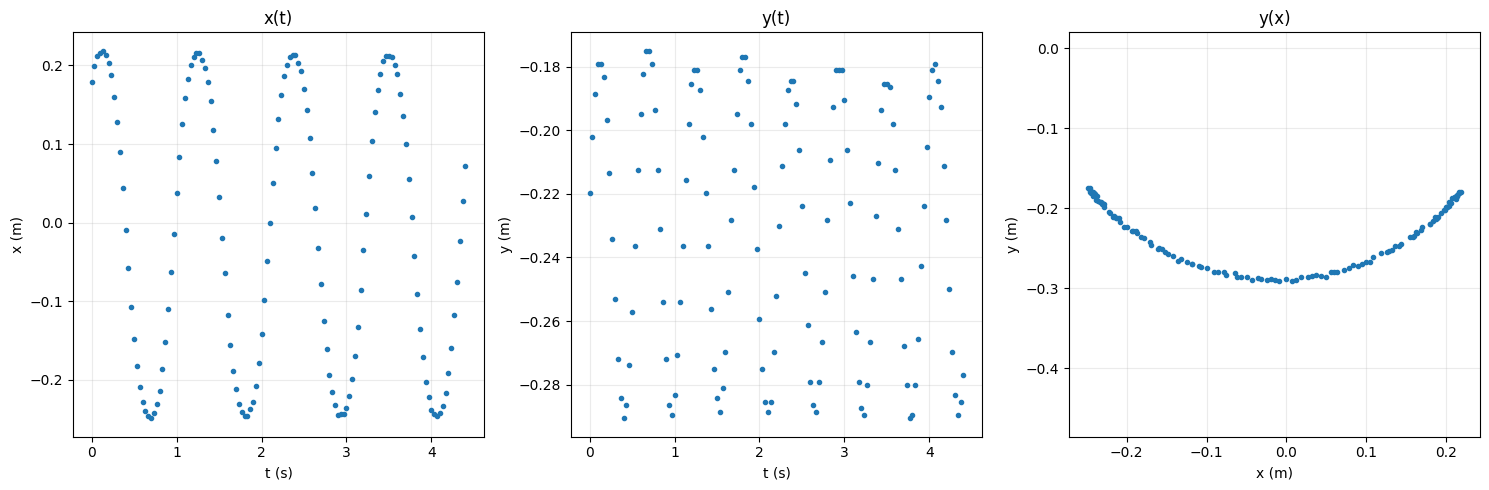

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(131)
plt.plot(t, x1, '.')
plt.xlabel("t (s)")
plt.ylabel("x (m)")
plt.title("x(t)")

plt.subplot(132)
plt.plot(t, y1, '.')
plt.xlabel("t (s)")
plt.ylabel("y (m)")
plt.title("y(t)")

plt.subplot(133)
plt.plot(x1, y1, '.')
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("y(x)")
plt.axis('equal')
plt.tight_layout()
plt.show()


## 2. Angle $\theta(t)$ et ajustement sinusoïdal

Pour de petits angles on peut utiliser $\theta \simeq \arcsin(x/l)$ si l'origine a été choisie convenablement.


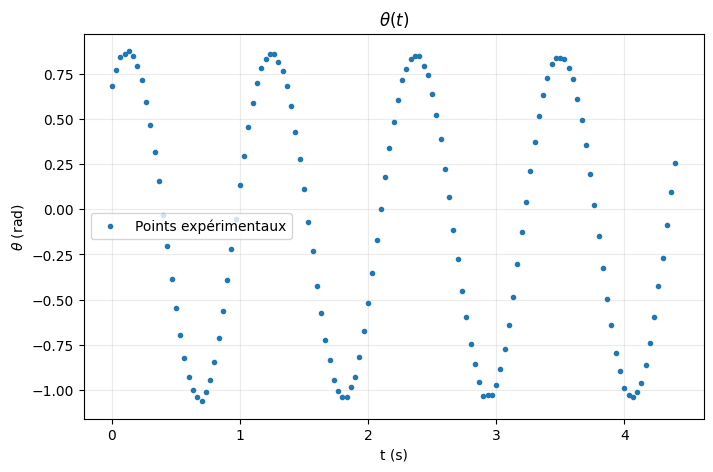

Valeur moyenne avant correction : -0.07488462316674147 rad
Valeur moyenne après correction : 5.843279076974508e-18 rad


In [ ]:
theta = np.arcsin(x1/l)

plt.figure()
plt.plot(t, theta, '.', label='Points expérimentaux')
plt.xlabel('t (s)')
plt.ylabel(r'$\theta$ (rad)')
plt.title(r'$\theta(t)$')
plt.legend()
plt.show()

print("Valeur moyenne avant correction :", theta.mean(), "rad")
theta = theta - theta.mean()
print("Valeur moyenne après correction :", theta.mean(), "rad")


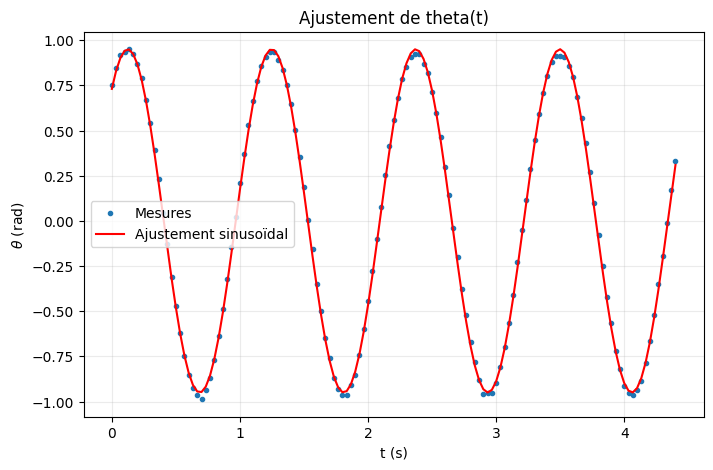

Période théorique T0 = 1.0714928084192015 s
Période mesurée T = 1.1244114961295992 s


In [ ]:
def my_sin(t, periode, amplitude, phase):
    return np.sin(2*np.pi*t/periode + phase) * amplitude

guess_periode = 2*np.pi*np.sqrt(l/g)
guess_amplitude = max(abs(theta))
guess_phase = 0
p0 = [guess_periode, guess_amplitude, guess_phase]

fit, covariance = curve_fit(my_sin, t, theta, p0=p0)
periode, amplitude, phase = fit

plt.figure()
plt.plot(t, theta, '.', label='Mesures')
plt.plot(t, my_sin(t, *fit), 'r', label='Ajustement sinusoïdal')
plt.xlabel('t (s)')
plt.ylabel(r'$\theta$ (rad)')
plt.title('Ajustement de theta(t)')
plt.legend()
plt.show()

print("Période théorique T0 =", guess_periode, "s")
print("Période mesurée T =", periode, "s")


<div style="background:#eaf4ff; border-left:6px solid #1f77b4; padding:12px 14px; border-radius:6px;">

### Commentaire sur le caractère sinusoïdal

La fonction est-elle sinusoïdale malgré une amplitude de l'ordre de 60° ? La période mesurée est-elle compatible avec la période théorique des petites oscillations ?

**Réponse rédigée :**

On remarque, à l'oeil que la courbe obtenue est bien d'allure sinusoidale mais la période d'oscillation est supérieure à celle attendue ce qui traduit le caractère non linéaire du système si l'amplitude est élevée.

</div>

## 3. Vitesse angulaire et portrait de phase


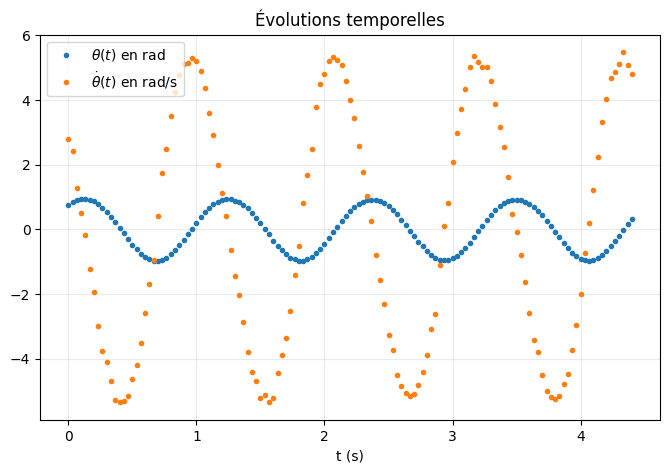

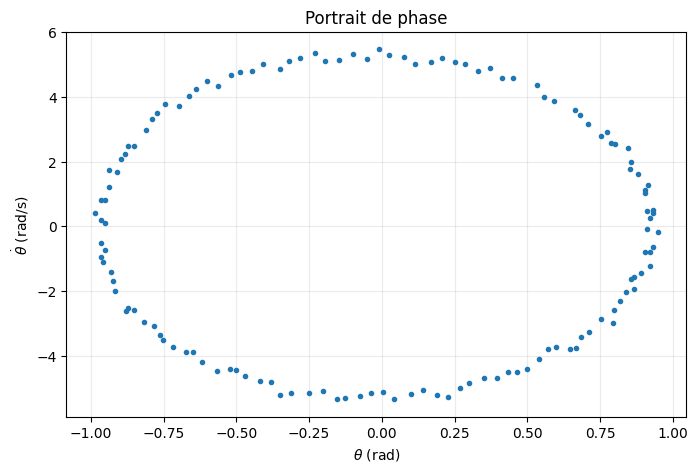

In [ ]:
dtheta = np.gradient(theta, t)

plt.figure()
plt.plot(t, theta, '.', label=r'$\theta(t)$ en rad')
plt.plot(t, dtheta, '.', label=r'$\dot\theta(t)$ en rad/s')
plt.xlabel('t (s)')
plt.title('Évolutions temporelles')
plt.legend()
plt.show()

plt.figure()
plt.plot(theta, dtheta, '.')
plt.xlabel(r'$\theta$ (rad)')
plt.ylabel(r'$\dot\theta$ (rad/s)')
plt.title('Portrait de phase')
plt.show()


## 4. Étude énergétique

On calcule :

$$E_c=\frac12m(l\dot\theta)^2, \qquad E_p=mgl(1-\cos\theta).$$


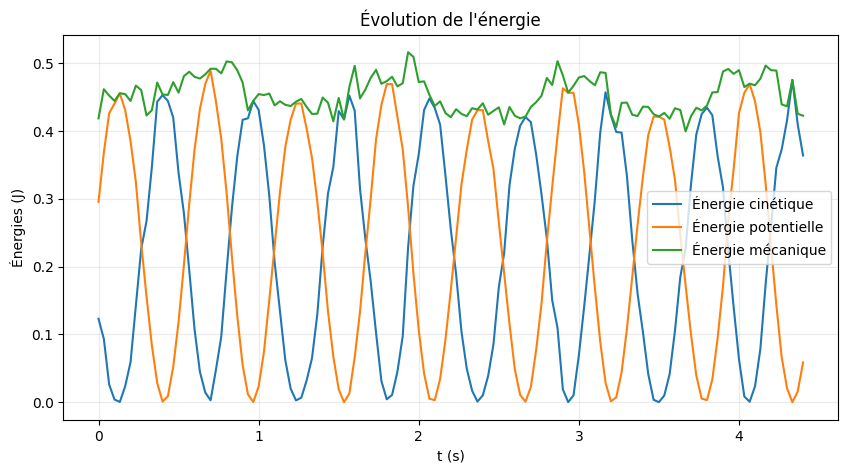

In [ ]:
Ec = 0.5*m*(l*dtheta)**2
Ep = m*g*l*(1-np.cos(theta))
Em = Ec + Ep

plt.figure(figsize=(10,5))
plt.plot(t, Ec, label='Énergie cinétique')
plt.plot(t, Ep, label='Énergie potentielle')
plt.plot(t, Em, label='Énergie mécanique')
plt.xlabel('t (s)')
plt.ylabel('Énergies (J)')
plt.title("Évolution de l'énergie")
plt.legend()
plt.show()


<div style="background:#eaf4ff; border-left:6px solid #1f77b4; padding:12px 14px; border-radius:6px;">

### Conclusion générale

Répondre aux objectifs : période mesurée, non-linéarité éventuelle, amortissement, portrait de phase et conservation ou non de l'énergie mécanique.

**Conclusion rédigée :**

On observe ici encore des valeurs assez proches de celles attendues (fonctions sinusoidales). On voit également une diminution de l'énergie mécanique totale, c'est du aux frottements. De plus la période est plus importante que celle attendue, il n'y a pas isochronisme mais il faudrait refaire d'autres mesures (angle plus important) pour le confirmer.

</div>

## Évaluation par compétences

Partie à compléter par le professeur au moment de la correction.

| Compétence évaluée | Barème |
|---|---:|
| Rappeler les objectifs du TP | /1 |
| Expliquer succinctement la problématique de chaque manipulation effectuée : que cherche-t-on à mesurer et pourquoi ? | /3 |
| Écrire précisément le protocole de mesure utilisé : appareillage, figures descriptives, difficultés rencontrées | /3 |
| Présenter les valeurs mesurées : tableaux, courbes annotées, valeurs avec incertitudes justifiées et commentées | /3 |
| Interpréter les résultats obtenus : comparaison aux valeurs attendues, explication des écarts éventuels | /3 |
| Nombre de questions résolues | /3 |

La note est calculée avec la formule :

$$20\times\left(0,9+\frac{a}{10}\right)\times\left(0,7+\frac{b}{10}\right)\times\left(0,7+\frac{c}{10}\right)\times\left(0,7+\frac{d}{10}\right)\times\left(0,7+\frac{e}{10}\right)\times\left(0,7+\frac{f}{10}\right)$$

avec $a$ la note d'objectifs, puis $b,c,d,e,f$ les notes sur 3 pour les autres compétences.


In [ ]:
# Grille d'évaluation interactive à compléter par le professeur
# Si les boutons s'affichent, cliquer sur les scores : la note se recalcule automatiquement.
# Si les boutons ne sont pas disponibles, utiliser la partie "saisie numérique" affichée en bas.

def note_grille(objectifs, problematique, protocole, presentation, interpretation, questions):
    return 20 * (0.9 + objectifs/10) \
              * (0.7 + problematique/10) \
              * (0.7 + protocole/10) \
              * (0.7 + presentation/10) \
              * (0.7 + interpretation/10) \
              * (0.7 + questions/10)

def couleur_note(note):
    note = max(0, min(20, note))
    # 0/20 : rouge ; 10/20 : jaune-orangé ; 20/20 : vert.
    teinte = 120 * note / 20
    return f"hsl({teinte:.0f}, 75%, 38%)"

def bloc_note_html(note):
    couleur = couleur_note(note)
    return f"""
    <div style="margin-top:12px; padding:14px 18px; border:2px solid {couleur};
                border-radius:8px; background:{couleur}; color:white;
                font-size:1.35em; font-weight:700; display:inline-block;">
        Note calculée : {note:.1f} / 20<br>
        Note arrondie : {round(note)} / 20
    </div>
    """

try:
    import ipywidgets as widgets
    from IPython.display import display, HTML, clear_output

    criteres = [
        ("Objectifs", 1),
        ("Problématique", 3),
        ("Protocole", 3),
        ("Présentation", 3),
        ("Interprétation", 3),
        ("Questions résolues", 3),
    ]
    boutons = []
    lignes = []
    for nom, maximum in criteres:
        bouton = widgets.ToggleButtons(
            options=[(str(i), i) for i in range(maximum + 1)],
            value=0,
            description=nom,
            disabled=False,
            button_style="",
            layout=widgets.Layout(width="100%"),
            style={"description_width": "160px"},
        )
        boutons.append(bouton)
        lignes.append(bouton)
    sortie = widgets.Output()

    def afficher_note(*args):
        note = note_grille(*(bouton.value for bouton in boutons))
        with sortie:
            clear_output(wait=True)
            display(HTML(bloc_note_html(note)))

    for bouton in boutons:
        bouton.observe(afficher_note, names="value")
    display(widgets.VBox(lignes + [sortie]))
    afficher_note()

except ModuleNotFoundError:
    from IPython.display import display, HTML
    print("Les boutons interactifs ne sont pas disponibles dans cet environnement.")
    print("Utiliser alors la saisie numérique ci-dessous, puis réexécuter la cellule.")
    objectifs = 0
    problematique = 0
    protocole = 0
    presentation = 0
    interpretation = 0
    questions = 0
    note = note_grille(objectifs, problematique, protocole, presentation, interpretation, questions)
    display(HTML(bloc_note_html(note)))